In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
results = pd.read_pickle('../sim/data/simulation_results_20260312_074037.pkl')

In [3]:
results.keys()

dict_keys(['runs', 'micro_logs', 'macro_logs', 'opportunity_logs', 'accounts_state', 'opportunities_state', 'leads_state'])

In [4]:
results['runs']['0']['reps']

{'005ak00000TI0yYAAT': {'earnings': 281894.0710947353,
  'strategy': 'Whale Hunter'},
 '005ak00000TI3rZAAT': {'earnings': 186970.21048944735,
  'strategy': 'Volume Chaser'},
 '005ak00000TI49JAAT': {'earnings': 218039.2343710668,
  'strategy': 'Momentum Follower'},
 '005ak00000TI4KbAAL': {'earnings': 231281.19841845433,
  'strategy': 'Steady Closer'}}

In [5]:
rows = []

for run_id, run_data in results['runs'].items():
    accounts = run_data.get("accounts", {})
    # print(accounts)
    # break
#     # build a lookup: account_id -> rep_id
    account_rep = {a_id: a_data.get("rep_id") for a_id, a_data in accounts.items()}
    # print(account_rep)
    for opp_id, opp_data in run_data.get("opportunities", {}).items():
        # get the rep from owning account
        rep_id = opp_data.get("rep_id") 
        
        rows.append({
            "run_id": run_id,
            "opportunity_id": opp_id,
            "rep_id": rep_id,
            "stage_final": opp_data.get("stage_final"),
            "won": opp_data.get("won"),
            "revenue": opp_data.get("revenue", 0),
            'commission': opp_data['commission'],
            "sentiment": opp_data.get("sentiment", 0),
            "sentiment_history": opp_data.get("sentiment_history", []),
            # "sentiment_mean": sentiment_mean,
            # 'sentiment_std': sentiment_std
            
            
        })

# create a DataFrame
opp_df = pd.DataFrame(rows)
    
    
opp_df['run_id'] = opp_df['run_id'].astype(int)

In [6]:
opp_df

,run_id,opportunity_id,rep_id,stage_final,won,revenue,commission,sentiment,sentiment_history
0,0,209c2f26-a889-410d-8628-7ce5a189d99e,005ak00000TI3rZAAT,Closed Lost,False,8717.519377,435.88,0.164097,"[0.4393915719155026, -0.2883504507636562, -0.1..."
1,0,c8569c9c-197d-48e2-a5c2-6337ca65caf6,005ak00000TI3rZAAT,Closed Dead,False,514735.487451,25736.77,2.323725,"[-0.161, 0.029384872931260533, 0.6285946428761..."
2,0,fed9d75e-1f25-422c-8296-e6b21ac401b9,005ak00000TI3rZAAT,Closed Lost,False,27092.067322,1354.60,0.248192,"[-0.14486021924709835, 0.6015077776419869, -0...."
3,0,e402ff42-7381-4aab-a281-0ee476ef2e9c,005ak00000TI3rZAAT,Closed Lost,False,34491.446615,1724.57,-0.708964,"[-0.047586061479976446, 0.49867262218668396, 2..."
4,0,245e186b-f2e5-43a6-a3e7-eb294fdddf96,005ak00000TI3rZAAT,Closed Lost,False,24916.483990,1245.82,0.518115,"[-0.2612610454759636, -0.3014104559833033, 0.2..."
...,...,...,...,...,...,...,...,...,...
5596,14,28847d08-42bf-47a7-9344-5b57b8f55f5d,005ak00000TI0yYAAT,Proposal,False,9905.813578,495.29,-1.333668,"[0.1558183530706203, 0.014589910872278969, -0...."
5597,14,b0ddbd5a-42a3-4aa6-823a-3724005938b0,005ak00000TI0yYAAT,Qualification,False,42293.884833,2114.69,-0.532798,"[-0.161, 0.2622195721931779, -0.18420554853136..."
5598,14,dbbc96d8-55d1-4c6d-9708-da86c1d21bd9,005ak00000TI49JAAT,Prospecting,False,9750.871206,487.54,-0.989055,[-0.989055125226769]
5599,14,3f38e5c2-3714-4146-b21b-724af60e8109,005ak00000TI49JAAT,Prospecting,False,39859.334789,1992.97,-0.151000,[-0.15100000000000002]


In [7]:
rows = []

for run_id, run_data in results['runs'].items():
    accounts = run_data.get("accounts", {})
    
    # build a lookup: account_id -> rep_id
    # account_rep = {a_id: a_data.get("rep_id") for a_id, a_data in accounts.items()}
    
    for opp_id, opp_data in run_data.get("leads", {}).items():
        # get the rep from owning account
        rep_id = opp_data.get("rep_id")
        # if opportunity doesn't store account_id, you'll need to map differently
        
        
        
        
        history = opp_data.get("sentiment_history", [])
        n = len(history)

        sentiment_mean = sum(history) / max(n, 1)

        if n > 1:
            sentiment_var = sum((x - sentiment_mean) ** 2 for x in history) / (n - 1)
            sentiment_std = sentiment_var ** 0.5
        else:
            sentiment_std = 0

        
        
        
        
        
        
        rows.append({
            "run_id": run_id,
            "opportunity_id": opp_id,
            "rep_id": rep_id,
            "stage_final": opp_data.get("stage_final"),
            "won": opp_data.get("converted"),
            "revenue": opp_data.get("revenue", 0),
            'commission': opp_data.get('commission', 0),
            "sentiment": opp_data.get("sentiment", 0),
            "sentiment_history": opp_data.get("sentiment_history", []),
            # "sentiment_mean": sentiment_mean,
            # 'sentiment_std': sentiment_std
        })

# create a DataFrame
lead_df = pd.DataFrame(rows)
lead_df['run_id'] = lead_df['run_id'].astype(int)

In [8]:
# df = opp_df
df = pd.concat([lead_df, opp_df])
# df = df[
#     df['stage_final'].isin(['Closed Lost', 'Closed Won', 'Closed Converted', 'Closed Dead'])
# ].copy().reset_index(drop = True)

In [9]:
macro = pd.DataFrame(results['macro_logs'])

macro = macro.sort_values(["run_id", "entity_id", "day"])

macro["next_day"] = (
    macro
    .groupby(["run_id", "entity_id"])["day"]
    .shift(-1)
)

macro['days_in_stage'] = macro['next_day'] - macro['day']


micro = pd.DataFrame(results['micro_logs'])

(array([  15.,   91.,  400., 1072., 1626., 1384.,  680.,  266.,   63.,
           4.]),
 array([ 3.69635147,  4.47939931,  5.26244715,  6.04549498,  6.82854282,
         7.61159066,  8.3946385 ,  9.17768634,  9.96073417, 10.74378201,
        11.52682985]),
 <a list of 10 Patch objects>)

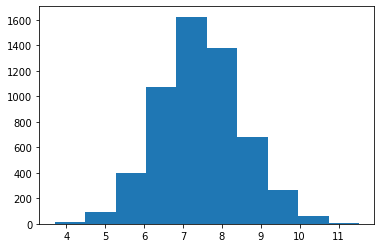

In [10]:
plt.hist(np.log(opp_df['commission']))

In [11]:
macro['macro_name'].value_counts()

Advance Stage               14580
New Lead                     7455
Close Opportunity            4485
Random Buy Opportunity       3228
Lead Conversion              2223
Spawn Account                2223
Spawn Opportunity            2223
Decay / Lost                  751
Base Opportunity Created      150
Lead Created                   60
Name: macro_name, dtype: int64

In [12]:
micro['action'].value_counts()

make_call                49372
send_email               49237
research_account         49177
hold_meeting             22950
follow_up                22940
send_proposal            21770
internal_prep            17741
solution_design          13682
stakeholder_alignment     5886
Name: action, dtype: int64

(array([25982.,  8425., 13822., 27442., 52386., 54074., 28706., 13582.,
         7398., 17490.]),
 array([-2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5]),
 <a list of 10 Patch objects>)

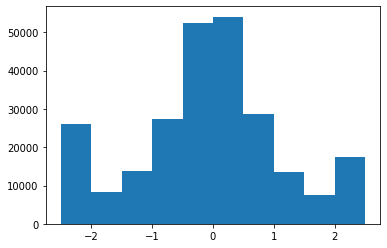

In [13]:
plt.hist(micro['sentiment_delta'])

(array([25994.,  6632., 12910., 31545., 56188., 54542., 28409., 12837.,
         6085., 14165.]),
 array([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.]),
 <a list of 10 Patch objects>)

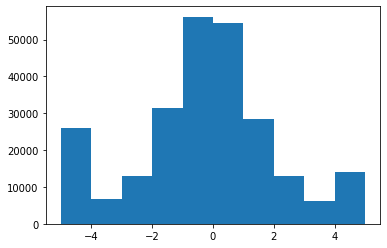

In [14]:
plt.hist(micro['sentiment_total'])

Advance Stage


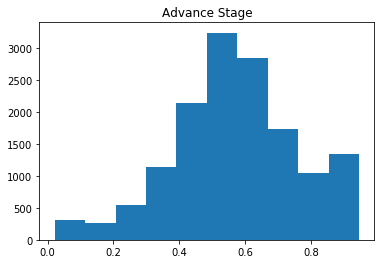

Close Opportunity


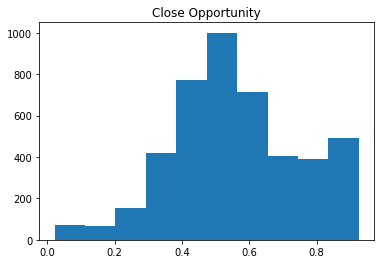

Decay / Lost


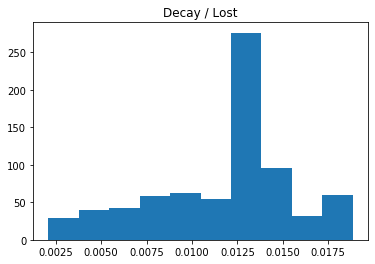

Lead Conversion


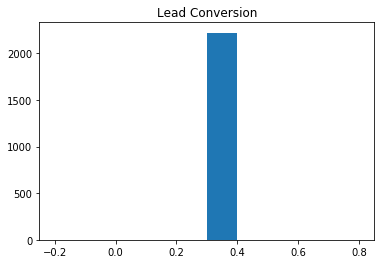

In [15]:
for m in ['Advance Stage', 'Close Opportunity', 'Decay / Lost', 'Lead Conversion']:
    print(m)
    plt.hist(macro[macro['macro_name'] == m]['probability'])
    plt.title(m)
    plt.show()

In [16]:
# crash()

(array([1090.,  323.,  628., 8135., 2859., 4245., 3684., 2237., 1517.,
        1767.]),
 array([0.0021    , 0.09657086, 0.19104172, 0.28551258, 0.37998344,
        0.47445429, 0.56892515, 0.66339601, 0.75786687, 0.85233773,
        0.94680859]),
 <a list of 10 Patch objects>)

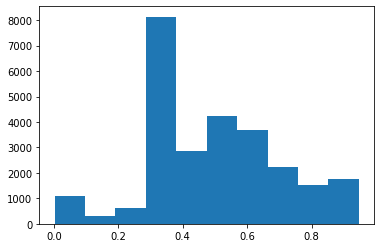

In [17]:
plt.hist(macro['probability'])

In [18]:
micro.groupby("action")["entity_id"].min()

action
follow_up                001922cc-54e3-40d1-9e5d-9df1b9737407
hold_meeting             001922cc-54e3-40d1-9e5d-9df1b9737407
internal_prep            001922cc-54e3-40d1-9e5d-9df1b9737407
make_call                001922cc-54e3-40d1-9e5d-9df1b9737407
research_account         001922cc-54e3-40d1-9e5d-9df1b9737407
send_email               001922cc-54e3-40d1-9e5d-9df1b9737407
send_proposal            001922cc-54e3-40d1-9e5d-9df1b9737407
solution_design          001922cc-54e3-40d1-9e5d-9df1b9737407
stakeholder_alignment    001922cc-54e3-40d1-9e5d-9df1b9737407
Name: entity_id, dtype: object

In [19]:
for i in df['run_id'].unique():
    df_temp = df[df['run_id'] == i].copy()
    break

In [20]:
opp_rows = [
    # 'opportunity_id',
    # 'rep_id',
    # 'revenue',
    # 'stage_history' '(days in stage)',
    'activity_count',
    'avg activity per day',
    'avg activity per stage'
    'cycle_time',
    'median_sentiment',
    'initial_sentiment',
    'final_sentiment',
    'std_sentiment',
    'closed_won'
]

In [21]:
opps = []
oppsdfds = 0

for run_id in tqdm(range(15)):

    run_df = df[df['run_id'] == run_id].copy()
    run_macro = macro[macro['run_id'] == run_id].copy()
    run_micro = micro[micro['run_id'] == run_id].copy()

    sim_end = run_macro["day"].max()

    for op in run_df['opportunity_id'].unique():
        won = run_df[run_df['opportunity_id'] == op]['won'].values[0]
        opp_df = run_df[run_df['opportunity_id'] == op]
        rep_id = opp_df['rep_id'].values[0]
        revenue = opp_df['revenue'].values[0]
        commish = opp_df['commission'].values[0]
        # -----------------------------
        # Macro slice for this opp
        # -----------------------------
        stages = (
            run_macro[run_macro['entity_id'] == op]
            .sort_values("day")
            .reset_index(drop=True)
        )

        if stages.empty:
            continue

        # Logical stages
        if stages['macro_name'].str.contains("Lead").any():
            stages_real = stages.iloc[[0]]
        else:
            stages_real = (
                stages[~stages['new_stage'].str.contains("Closed", na=False)]
                .groupby("new_stage", as_index=False)
                .agg({"day": "min"})
            )

        n_stages = len(stages_real)

        # -----------------------------
        # Micro slice for this opp
        # -----------------------------
        micro_opp = run_micro[run_micro['entity_id'] == op]
        activity_count = len(micro_opp)

        # -----------------------------
        # Compute micro actions per stage window
        # -----------------------------
        activity_per_stage = []
        stage_days = stages_real["day"].values.tolist() + [sim_end]

        for i in range(n_stages):
            start_day = stage_days[i]
            end_day = stage_days[i + 1]

            n_micro = micro_opp[
                (micro_opp["day"] >= start_day) &
                (micro_opp["day"] < end_day)
            ].shape[0]

            activity_per_stage.append(n_micro)

        avg_micro_per_stage = np.mean(activity_per_stage) if activity_per_stage else 0
        stage_days_diff = np.diff(stage_days)
        avg_days_in_stage = np.mean(stage_days_diff) if len(stage_days_diff) > 0 else 0

        # -----------------------------
        # Cycle time (first to last touch)
        # -----------------------------
        macro_days = stages['day'].values
        cycle_time = macro_days.max() - macro_days.min() if len(macro_days) > 0 else 0

        # -----------------------------
        # Sentiment
        # -----------------------------
        hist_lists = opp_df['sentiment_history'].tolist()
        all_history = [s for sublist in hist_lists for s in sublist]

        sentiment_median = np.median(all_history) if all_history else np.nan
        sentiment_std = np.std(all_history, ddof=1) if len(all_history) > 1 else 0.0
        final_sentiment = opp_df['sentiment'].values[-1]

        # -----------------------------
        # Store results
        # -----------------------------
        activity_velocity = activity_count / cycle_time if cycle_time > 0 else 0
        stage_velocity = n_stages / cycle_time if cycle_time > 0 else 0
        early_activity = activity_per_stage[0] if activity_per_stage else 0
        late_activity = activity_per_stage[-1] if activity_per_stage else 0
        activity_balance = avg_micro_per_stage / n_stages if n_stages > 0 else 0

        opps.append({
            'run_id': run_id,
            'entity': f'{op}_{oppsdfds}',
            'rep_id': rep_id,
            'revenue': revenue,
            'commission': commish,

            'n_stages': n_stages,
            'stage_final': opp_df['stage_final'].values[0],
            'avg_days_in_stage': avg_days_in_stage,
            'cycle_time': cycle_time,

            'activity_count': activity_count,
            'avg_micro_per_stage': avg_micro_per_stage,

            'activity_velocity': activity_velocity,
            'stage_velocity': stage_velocity,
            'early_activity': early_activity,
            'late_activity': late_activity,
            'activity_balance': activity_balance,

            'final_sentiment': final_sentiment,
            'sentiment_median': sentiment_median,
            'sentiment_std': sentiment_std,

            'won': won
        })
        oppsdfds += 1

100%|██████████| 15/15 [02:14<00:00,  8.99s/it]


In [22]:
df.to_pickle('../sim/data/df.pkl')

In [23]:
df = pd.DataFrame(opps)

In [24]:
df = df[
    df['stage_final'].isin(['Closed Lost', 'Closed Won', 'Closed Converted', 'Closed Dead'])
].copy().reset_index(drop = True)

In [25]:
df[df['stage_final'] == 'Closed Converted']['avg_micro_per_stage']

3        1.0
5        1.0
6        1.0
7        1.0
11       1.0
        ... 
12364    1.0
12367    1.0
12371    1.0
12373    1.0
12374    1.0
Name: avg_micro_per_stage, Length: 2223, dtype: float64

In [26]:
for rep, opps in df.groupby('rep_id'):
    print(rep_id)
    print((opps['revenue'].mean()))
    print(len(opps[opps['won'] == True]) / len(opps))
    print()
    print()

005ak00000TI49JAAT
3207098.516779653
0.4111825828797625


005ak00000TI49JAAT
3083152.680061104
0.375682382133995


005ak00000TI49JAAT
3066159.295289156
0.4711388455538221


005ak00000TI49JAAT
2914337.6451440817
0.3976721629485936




(array([3.55e+03, 9.79e+02, 1.21e+02, 3.10e+01, 1.10e+01, 1.00e+00,
        2.00e+00, 1.00e+00, 1.00e+00, 2.00e+00]),
 array([  1. ,  39.3,  77.6, 115.9, 154.2, 192.5, 230.8, 269.1, 307.4,
        345.7, 384. ]),
 <a list of 10 Patch objects>)

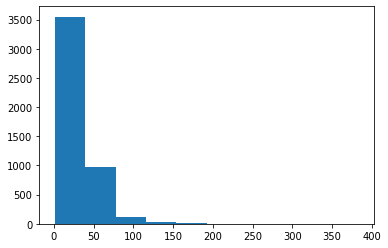

In [27]:
plt.hist(df[df['won'] == True]['activity_count'])

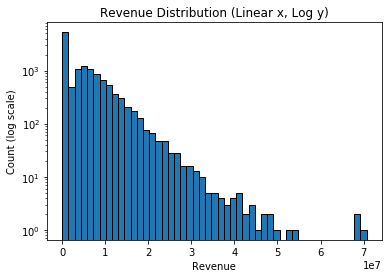

In [28]:
import numpy as np
import matplotlib.pyplot as plt

data = df['revenue']
data = data[data > 0]

# Use linear bins
bins = np.linspace(data.min(), data.max(), 50)  # 50 bins evenly spaced in linear space

plt.hist(data, bins=bins, edgecolor='k')
plt.yscale('log')  # optional
plt.xlabel('Revenue')
plt.ylabel('Count (log scale)')
plt.title('Revenue Distribution (Linear x, Log y)')
plt.show()

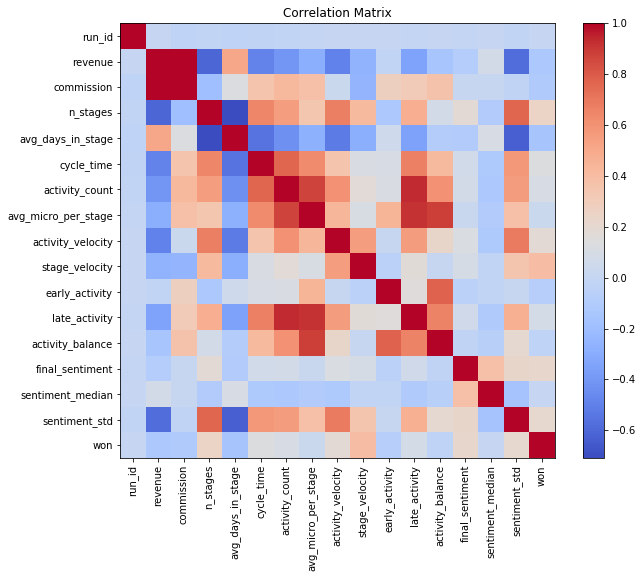

In [29]:
# =========================================
# 2️⃣ DESCRIPTIVE ANALYSIS (PLT & NP)
# =========================================

# Correlation matrix
corr = df.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

/home/simonhans/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1449: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


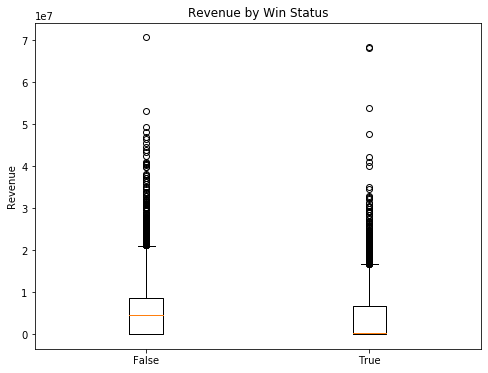

/home/simonhans/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1449: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


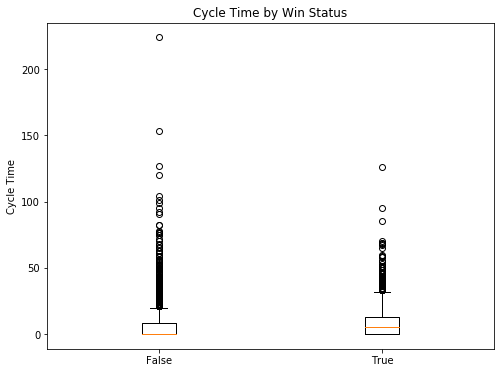

/home/simonhans/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1449: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


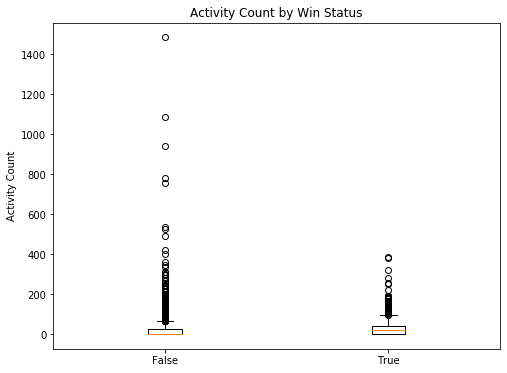

/home/simonhans/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1449: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


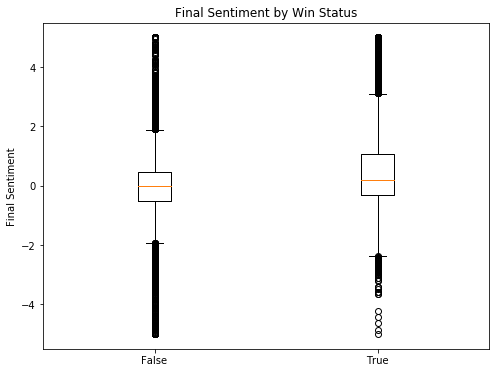

In [30]:
# Boxplot function using plt
def boxplot_manual(x, y, title, ylabel):
    labels = np.unique(x)
    data_to_plot = [y[x == lbl] for lbl in labels]
    plt.figure(figsize=(8,6))
    plt.boxplot(data_to_plot, labels=labels)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.show()

# Revenue by win
boxplot_manual(df['won'].values, df['revenue'].values, "Revenue by Win Status", "Revenue")

# Cycle time by win
boxplot_manual(df['won'].values, df['cycle_time'].values, "Cycle Time by Win Status", "Cycle Time")

# Activity count by win
boxplot_manual(df['won'].values, df['activity_count'].values, "Activity Count by Win Status", "Activity Count")

# Final sentiment by win
boxplot_manual(df['won'].values, df['final_sentiment'].values, "Final Sentiment by Win Status", "Final Sentiment")

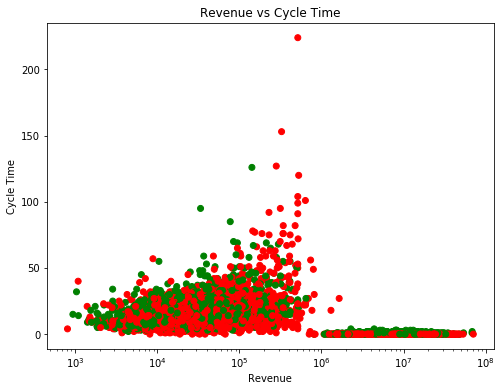

In [31]:
# Scatterplot function
def scatter_manual(x, y, color=None, title="", xlabel="", ylabel=""):
    plt.figure(figsize=(8,6))
    if color is None:
        color = 'b'
    plt.scatter(x, y, c=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xscale('log')
    # plt.yscale('log')
    # plt.legend()
    plt.show()

# Revenue vs cycle_time colored by win
colors = np.array(['red','green'])
scatter_manual(df['revenue'].values, df['cycle_time'].values, color=colors[df['won'].astype(int).values],
               title="Revenue vs Cycle Time", xlabel="Revenue", ylabel="Cycle Time")

In [32]:
df[df['won'] == True]

,run_id,entity,rep_id,revenue,commission,n_stages,stage_final,avg_days_in_stage,cycle_time,activity_count,avg_micro_per_stage,activity_velocity,stage_velocity,early_activity,late_activity,activity_balance,final_sentiment,sentiment_median,sentiment_std,won
3,0,ME8WZL5N_3,005ak00000TI3rZAAT,1.288105e+07,NaN,1,Closed Converted,300.000000,1,1,1.000000,1.000000,1.000000,1,1,1.000000,0.183591,0.183591,0.000000,True
5,0,OK9JQ1QO_5,None,6.096967e+06,NaN,1,Closed Converted,299.000000,0,1,1.000000,0.000000,0.000000,1,1,1.000000,-0.267745,-0.267745,0.000000,True
6,0,B01X8BMK_6,None,2.576470e+07,NaN,1,Closed Converted,299.000000,0,1,1.000000,0.000000,0.000000,1,1,1.000000,0.269650,0.269650,0.000000,True
7,0,DKDVK4WM_7,None,5.634017e+06,NaN,1,Closed Converted,299.000000,0,1,1.000000,0.000000,0.000000,1,1,1.000000,-0.501045,-0.501045,0.000000,True
11,0,O4QVUOXY_11,005ak00000TI3rZAAT,5.093043e+06,NaN,1,Closed Converted,299.000000,1,1,1.000000,1.000000,1.000000,1,1,1.000000,-0.126232,-0.126232,0.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741,14,3d7f8377-b725-4041-a5e8-b94d90b188c0_13085,005ak00000TI0yYAAT,1.752929e+04,876.464371,3,Closed Won,2.000000,16,32,8.000000,2.000000,0.187500,0,24,2.666667,1.542596,-0.075965,0.561074,True
12743,14,2c52a8f8-4df1-4a16-a3e8-2c1ac607f77a_13087,005ak00000TI3rZAAT,3.048234e+04,1524.117008,3,Closed Won,2.666667,15,28,3.333333,1.866667,0.200000,0,10,1.111111,-0.221844,-0.145000,0.540792,True
12746,14,fb1d6a1e-e2c1-473d-a5c3-0d2727880d2f_13090,005ak00000TI3rZAAT,9.742501e+04,4871.250498,4,Closed Won,0.250000,20,24,5.750000,1.200000,0.200000,0,5,1.437500,1.236020,-0.161000,0.576944,True
12747,14,e8c95f47-6d0e-434b-8130-50d62dc41090_13091,005ak00000TI4KbAAL,1.467610e+04,733.805227,3,Closed Won,1.666667,18,28,7.666667,1.555556,0.166667,0,23,2.555556,0.148983,-0.152500,0.570692,True


In [33]:
df['commission_pct'] = df['commission'] / df['revenue']

In [34]:
df['commission_pct'].mean()

0.05000358068646637

In [35]:
df['commission_pct'].std()

0.00018892865822033866

In [36]:
df['commission_pct'].max()

0.06173517881401094

In [37]:
df['commission_pct'].min()

0.04999782522874095

In [38]:
df['commission'].mean()

2986.033735048935

In [39]:
df['commission'].std()

4364.914094867135

In [40]:
df['commission'].min()

40.3

In [41]:
df['commission'].max()

101400.15

(array([4.961e+03, 2.080e+02, 5.400e+01, 1.000e+01, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([4.0300000e+01, 1.0176285e+04, 2.0312270e+04, 3.0448255e+04,
        4.0584240e+04, 5.0720225e+04, 6.0856210e+04, 7.0992195e+04,
        8.1128180e+04, 9.1264165e+04, 1.0140015e+05]),
 <a list of 10 Patch objects>)

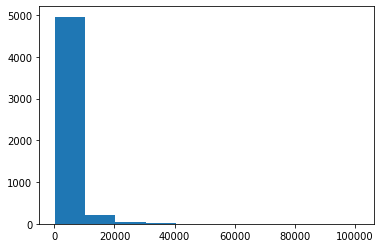

In [42]:
plt.hist(df['commission'])

In [43]:
# =========================================
# 3️⃣ REP-LEVEL PERFORMANCE
# =========================================
rep_summary = df.groupby('rep_id').agg(
    win_rate=('won', 'mean'),
    avg_revenue=('revenue', 'mean'),
        avg_commission=('commission', 'mean'),

    avg_cycle=('cycle_time', 'mean'),
    avg_activity=('activity_count', 'mean'),
    avg_sentiment=('final_sentiment', 'mean'),
    total_opps=('entity', 'count'),
).sort_values('win_rate', ascending=False)

print("\nRep-level Summary:")
print(rep_summary)


Rep-level Summary:
                    win_rate   avg_revenue  avg_commission  avg_cycle  \
rep_id                                                                  
005ak00000TI49JAAT  0.471139  3.066159e+06     2611.356084   9.261050   
005ak00000TI0yYAAT  0.411183  3.207099e+06     3048.513562   9.404255   
005ak00000TI4KbAAL  0.397672  2.914338e+06     2822.953022   9.700291   
005ak00000TI3rZAAT  0.375682  3.083153e+06     3454.083673   9.775682   

                    avg_activity  avg_sentiment  total_opps  
rep_id                                                       
005ak00000TI49JAAT     31.018721       0.714410        1923  
005ak00000TI0yYAAT     28.944582       0.309015        2021  
005ak00000TI4KbAAL     28.091174       0.008376        2062  
005ak00000TI3rZAAT     29.301737       0.058571        2015  
